In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [77]:
file_path = "/content/drive/MyDrive/ML_projects/Middle_East_Economic_Data_1990_2024_with_Oil.csv"
df = pd.read_csv(file_path)
df.head()

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel
0,Bahrain,BHR,1990,101.627082,1.907789,4.809511e+09,4.437997,9342.538914,83.201723,0.929335,72.587,NaN,23.0
1,Bahrain,BHR,1991,74.757141,11.800826,5.248911e+09,11.229998,10434.132396,84.110656,0.764420,72.668,1.047,20.0
2,Bahrain,BHR,1992,74.210844,16.078853,5.402232e+09,6.689998,10460.158322,85.081054,-0.172414,72.785,0.968,18.0
3,Bahrain,BHR,1993,73.764609,-4.650769,5.913001e+09,12.870007,11151.871496,70.998436,2.538860,72.939,0.882,19.0
4,Bahrain,BHR,1994,71.406483,3.289479,6.330628e+09,-0.250001,11629.359522,65.066988,0.816911,73.134,1.007,25.0


In [78]:
df.tail()

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel
450,Yemen,YEM,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.435,17.963,45.0
451,Yemen,YEM,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.019,18.312,70.0
452,Yemen,YEM,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.952,17.224,75.0
453,Yemen,YEM,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.295,16.944,80.0
454,Yemen,YEM,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.970,85.0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               455 non-null    object 
 1   Country_Code                          455 non-null    object 
 2   Year                                  455 non-null    int64  
 3   Exports_pct_GDP                       429 non-null    float64
 4   FDI_net_inflows_pct_GDP               446 non-null    float64
 5   GDP_current_USD                       448 non-null    float64
 6   GDP_growth_annual_pct                 447 non-null    float64
 7   GDP_per_capita_current_USD            448 non-null    float64
 8   Imports_pct_GDP                       429 non-null    float64
 9   Inflation_consumer_prices_annual_pct  395 non-null    float64
 10  Life_expectancy_years                 442 non-null    float64
 11  Unemployment_total_

In [80]:
df_numeric = df.select_dtypes(include=[np.number])
df_clean = df_numeric.dropna()

In [81]:
X = df_clean.drop(columns=['Life_expectancy_years'])
y = df_clean['Life_expectancy_years']

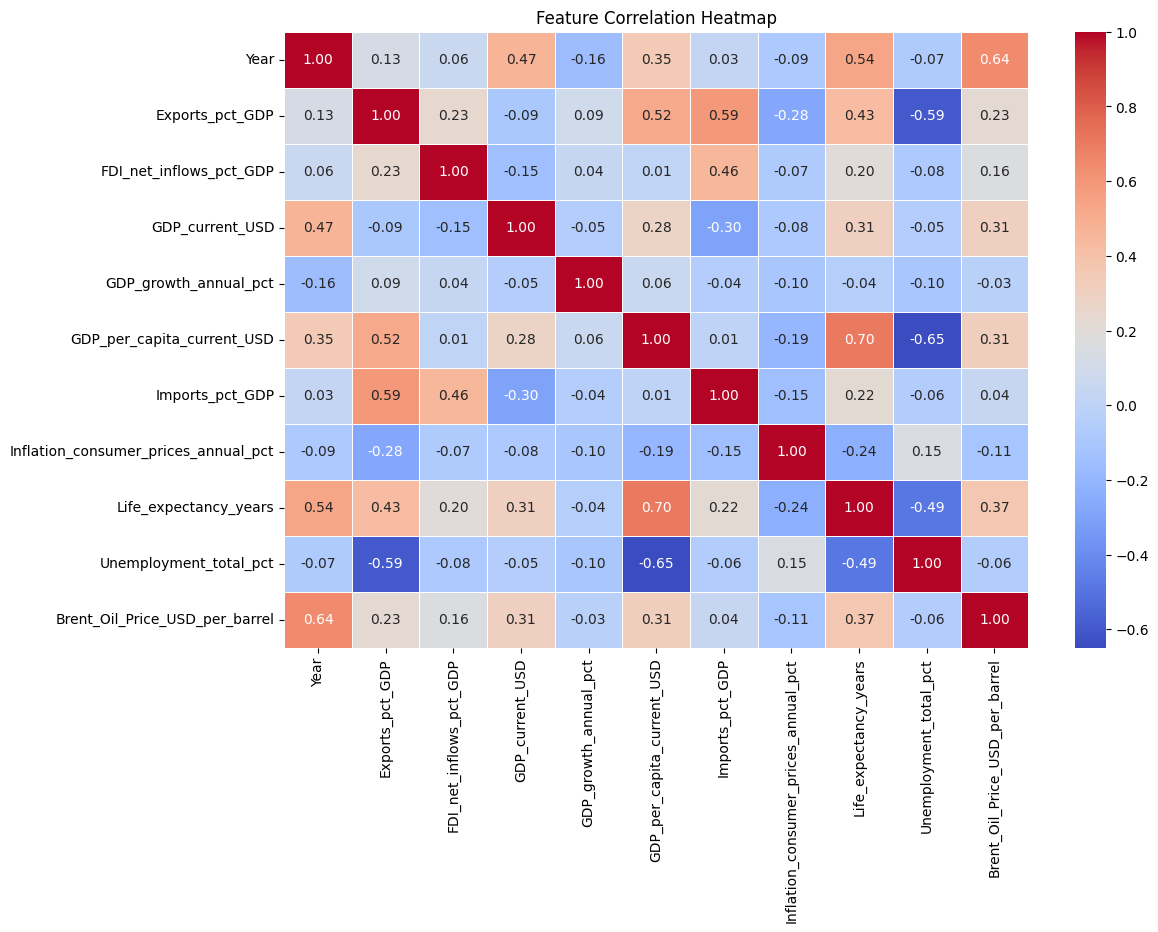

Correlation with Life Expectancy:
Life_expectancy_years                   1.000000
GDP_per_capita_current_USD              0.703816
Year                                    0.539678
Exports_pct_GDP                         0.433039
Brent_Oil_Price_USD_per_barrel          0.368037
GDP_current_USD                         0.305089
Imports_pct_GDP                         0.219143
FDI_net_inflows_pct_GDP                 0.198835
GDP_growth_annual_pct                  -0.040291
Inflation_consumer_prices_annual_pct   -0.242875
Unemployment_total_pct                 -0.485643
Name: Life_expectancy_years, dtype: float64


In [82]:
correlation_matrix = df_clean.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

print("Correlation with Life Expectancy:")
print(correlation_matrix['Life_expectancy_years'].sort_values(ascending=False))

In [83]:
X = df_clean[['GDP_per_capita_current_USD', 'Year', 'Exports_pct_GDP',
              'Unemployment_total_pct', 'Brent_Oil_Price_USD_per_barrel',
              'GDP_current_USD', 'Inflation_consumer_prices_annual_pct']]

y = df_clean['Life_expectancy_years']

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
metrics = ['manhattan', 'euclidean']
results = {}

for m in metrics:
    knn = KNeighborsRegressor(n_neighbors=7, weights='distance', metric=m)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    results[m] = {
        'R2': r2_score(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred)
    }

for m in metrics:
    print(f"--- Metric: {m.capitalize()} ---")
    print(f"R2 Score: {results[m]['R2']:.4f}")
    print(f"Mean Squared Error (MSE): {results[m]['MSE']:.4f}")
    print()

--- Metric: Manhattan ---
R2 Score: 0.9031
Mean Squared Error (MSE): 2.9083

--- Metric: Euclidean ---
R2 Score: 0.8955
Mean Squared Error (MSE): 3.1361

